**Задание**

Необходимо реализовать алгоритм DQN. В качестве среды можно использовать классические среды (в этом случае используется полносвязная архитектура нейронной сети) или игры Atari (в этом случае используется сверточная архитектура нейронной сети).

**Описание набора данных**

In [28]:
import sys
!{sys.executable} -m pip install torch gymnasium

In [29]:
import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


In [30]:
# Название среды
CONST_ENV_NAME = 'Acrobot-v1'
# Использование GPU
CONST_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Элемент ReplayMemory в форме именованного кортежа
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

In [31]:
# Реализация техники Replay Memory
class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        '''
        Сохранение данных в ReplayMemory
        '''
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        '''
        Выборка случайных элементов размера batch_size
        '''
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [32]:
class DQN_Model(nn.Module):

    def __init__(self, n_observations, n_actions):
        '''
        Инициализация топологии нейронной сети
        '''
        super(DQN_Model, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    def forward(self, x):
        '''
        Прямой проход
        Вызывается для одного элемента, чтобы определить следующее действие
        Или для batch'а во время процедуры оптимизации
        '''
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

In [33]:
class DQN_Agent:

    def __init__(self, env,
                 BATCH_SIZE = 128,
                 GAMMA = 0.99,
                 EPS_START = 0.9,
                 EPS_END = 0.05,
                 EPS_DECAY = 1000,
                 TAU = 0.005,
                 LR = 1e-4):

        self.env = env

        # Размерности Q-модели
        self.n_actions = env.action_space.n

        # Для gymnasium всегда возвращается кортеж
        state, info = self.env.reset()
        self.n_observations = len(state)

        # Коэффициенты
        self.BATCH_SIZE = BATCH_SIZE
        self.GAMMA = GAMMA
        self.EPS_START = EPS_START
        self.EPS_END = EPS_END
        self.EPS_DECAY = EPS_DECAY
        self.TAU = TAU
        self.LR = LR

        # Инициализация policy и target сетей
        self.policy_net = DQN_Model(self.n_observations, self.n_actions).to(CONST_DEVICE)
        self.target_net = DQN_Model(self.n_observations, self.n_actions).to(CONST_DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())

        # Оптимизатор и память
        self.optimizer = optim.AdamW(self.policy_net.parameters(), lr=self.LR, amsgrad=True)
        self.memory = ReplayMemory(10000)

        # Счетчик шагов
        self.steps_done = 0

        # Для графиков
        self.episode_durations = []

    def select_action(self, state):
        '''
        Выбор действия с использованием epsilon-greedy стратегии
        '''
        sample = random.random()
        eps_threshold = self.EPS_END + (self.EPS_START - self.EPS_END) * \
            math.exp(-1. * self.steps_done / self.EPS_DECAY)
        self.steps_done += 1

        if sample > eps_threshold:
            with torch.no_grad():
                return self.policy_net(state).max(1)[1].view(1, 1)
        else:
            return torch.tensor([[self.env.action_space.sample()]],
                              device=CONST_DEVICE, dtype=torch.long)

    def optimize_model(self):
        '''
        Один шаг оптимизации модели
        '''
        if len(self.memory) < self.BATCH_SIZE:
            return

        transitions = self.memory.sample(self.BATCH_SIZE)
        batch = Transition(*zip(*transitions))

        non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                              batch.next_state)),
                                    device=CONST_DEVICE, dtype=torch.bool)
        non_final_next_states = torch.cat([s for s in batch.next_state
                                                    if s is not None])

        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)

        state_action_values = self.policy_net(state_batch).gather(1, action_batch)

        next_state_values = torch.zeros(self.BATCH_SIZE, device=CONST_DEVICE)
        with torch.no_grad():
            next_state_values[non_final_mask] = self.target_net(non_final_next_states).max(1)[0]

        expected_state_action_values = (next_state_values * self.GAMMA) + reward_batch

        criterion = nn.SmoothL1Loss()
        loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()

    def plot_durations(self, show_result=False):
        '''
        Визуализация длительности эпизодов
        '''
        plt.figure(1)
        durations_t = torch.tensor(self.episode_durations, dtype=torch.float)
        if show_result:
            plt.title('Result')
        else:
            plt.clf()
            plt.title('Training...')
        plt.xlabel('Episode')
        plt.ylabel('Duration')
        plt.plot(durations_t.numpy())

        if len(durations_t) >= 100:
            means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
            means = torch.cat((torch.zeros(99), means))
            plt.plot(means.numpy())

        plt.pause(0.001)

    def learn(self, num_episodes=600):
        '''
        Основной цикл обучения
        '''
        for i_episode in range(num_episodes):
            # Gymnasium возвращает (state, info)
            state, info = self.env.reset()
            state = torch.tensor(state, dtype=torch.float32, device=CONST_DEVICE).unsqueeze(0)

            for t in count():
                action = self.select_action(state)

                # Gymnasium возвращает 5 значений: observation, reward, terminated, truncated, info
                observation, reward, terminated, truncated, info = self.env.step(action.item())
                done = terminated or truncated

                reward = torch.tensor([reward], device=CONST_DEVICE)

                if done:
                    next_state = None
                else:
                    next_state = torch.tensor(observation, dtype=torch.float32,
                                            device=CONST_DEVICE).unsqueeze(0)

                self.memory.push(state, action, next_state, reward)
                state = next_state

                self.optimize_model()

                # Soft update целевой сети
                target_net_state_dict = self.target_net.state_dict()
                policy_net_state_dict = self.policy_net.state_dict()
                for key in policy_net_state_dict:
                    target_net_state_dict[key] = policy_net_state_dict[key]*self.TAU + \
                                                target_net_state_dict[key]*(1-self.TAU)
                self.target_net.load_state_dict(target_net_state_dict)

                if done:
                    self.episode_durations.append(t + 1)
                    self.plot_durations()
                    break

            if i_episode % 50 == 0:
                print(f'Episode {i_episode}/{num_episodes}, Duration: {t + 1}')

        print('Training completed')
        self.plot_durations(show_result=True)
        plt.ioff()
        plt.show()

    def play_agent(self, num_episodes=5):
        '''
        Проигрывание обученного агента
        '''
        for i_episode in range(num_episodes):
            state, info = self.env.reset()
            state = torch.tensor(state, dtype=torch.float32, device=CONST_DEVICE).unsqueeze(0)

            total_reward = 0
            for t in count():
                with torch.no_grad():
                    action = self.policy_net(state).max(1)[1].view(1, 1)

                observation, reward, terminated, truncated, info = self.env.step(action.item())
                done = terminated or truncated

                total_reward += reward

                if done:
                    print(f'Episode {i_episode + 1}: Duration = {t + 1}, Total Reward = {total_reward}')
                    break

                state = torch.tensor(observation, dtype=torch.float32,
                                   device=CONST_DEVICE).unsqueeze(0)

        self.env.close()


# Работа программы

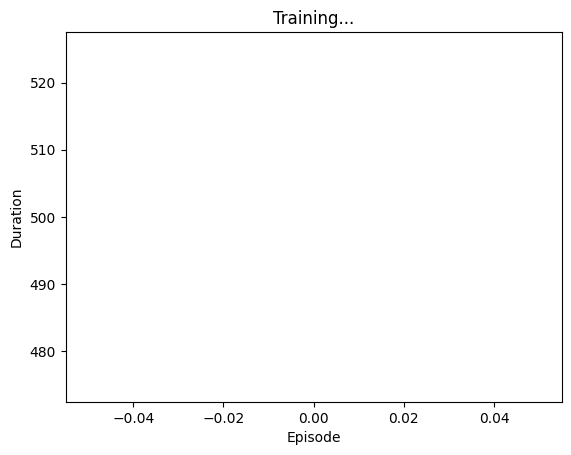

Episode 0/30, Duration: 500


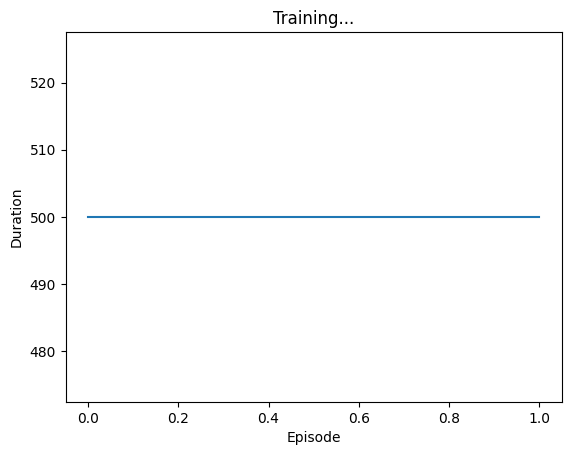

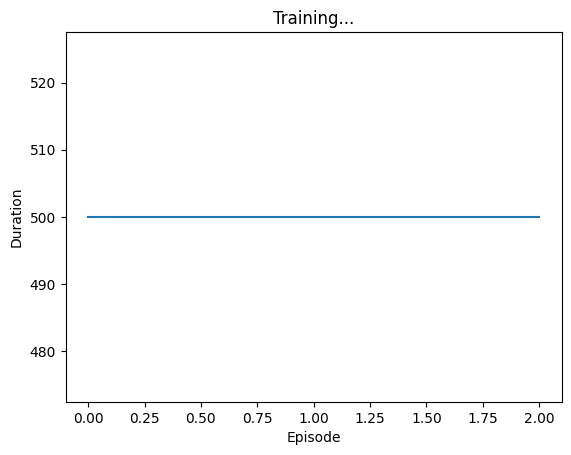

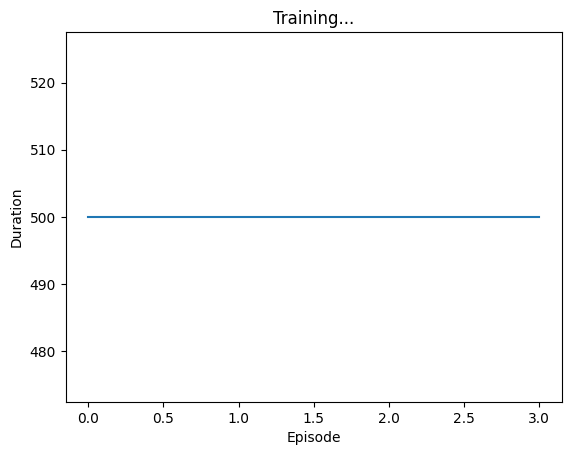

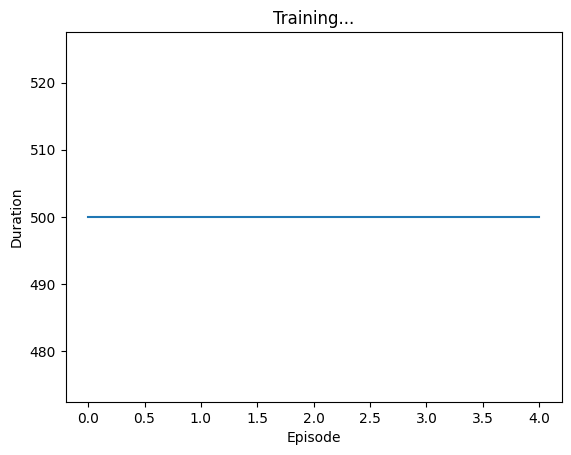

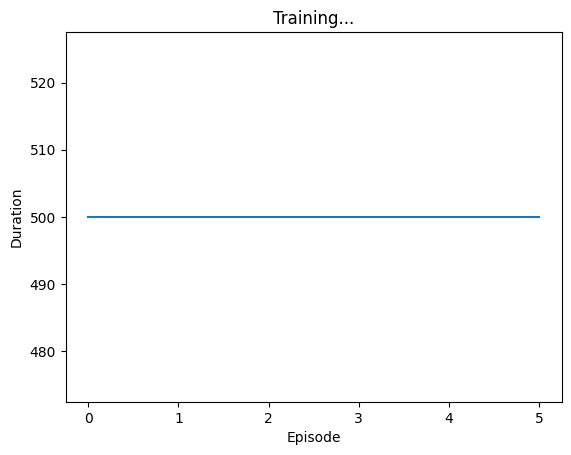

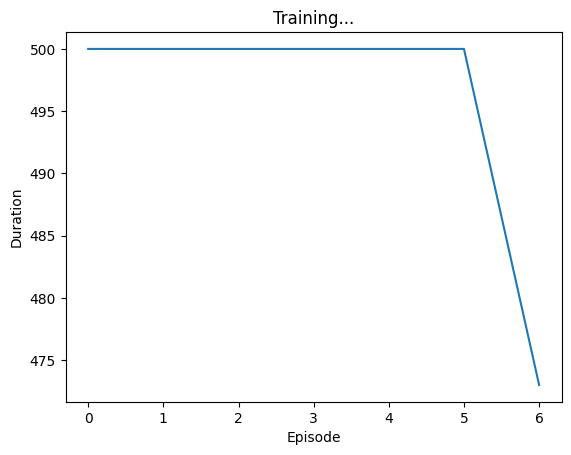

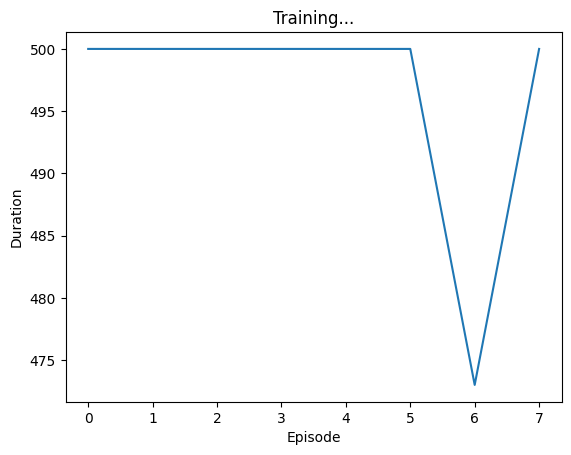

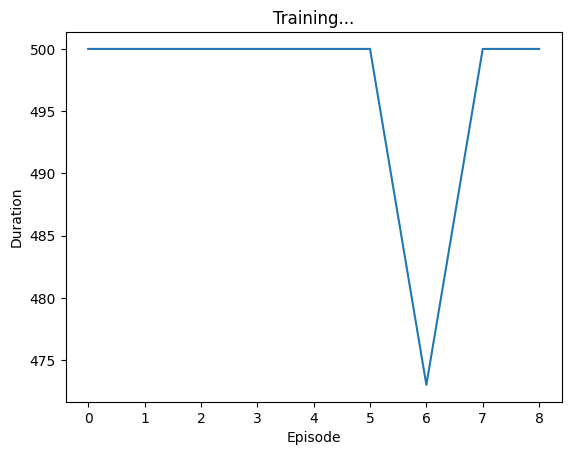

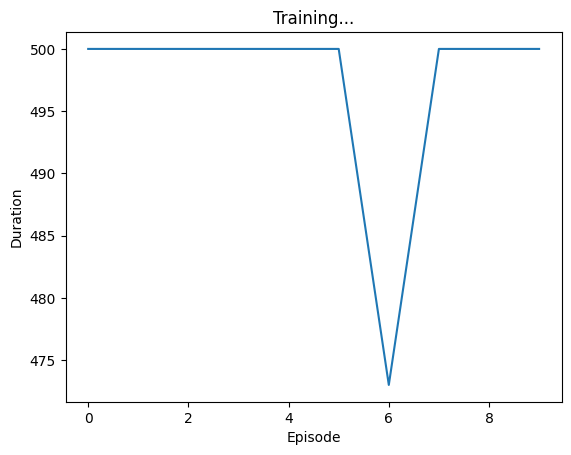

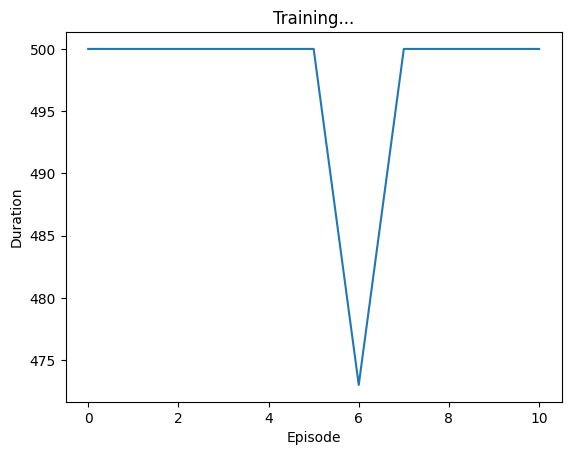

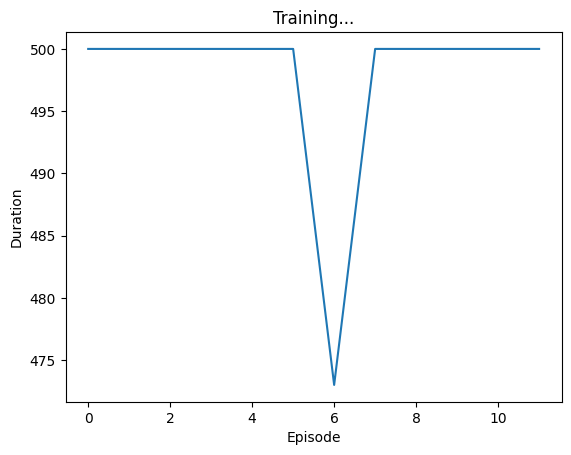

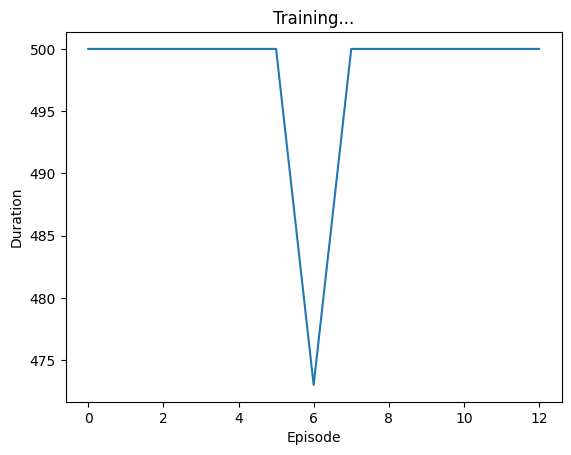

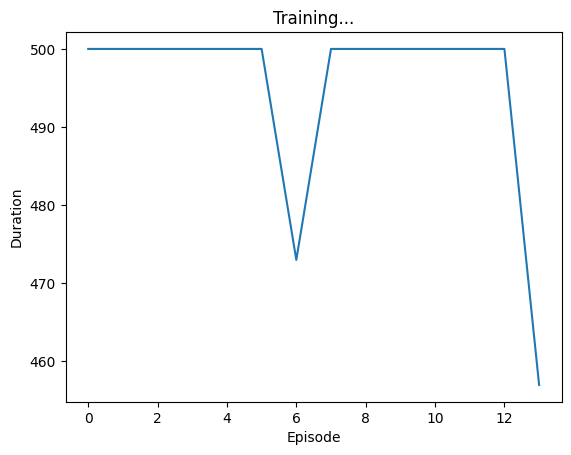

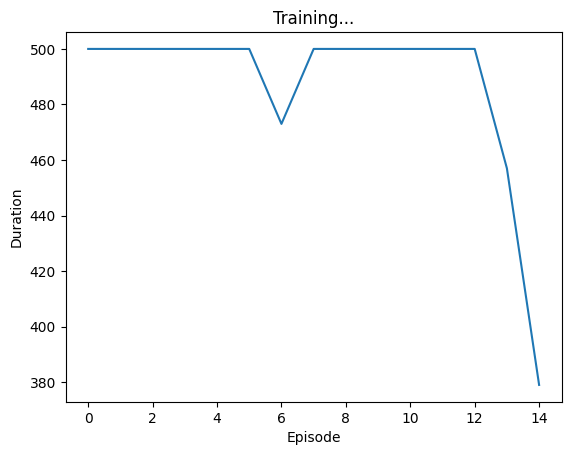

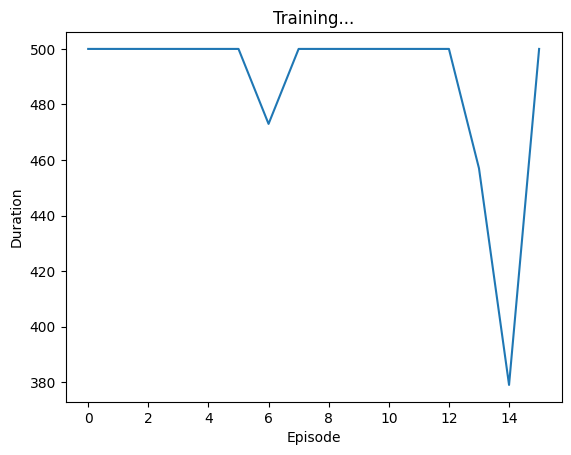

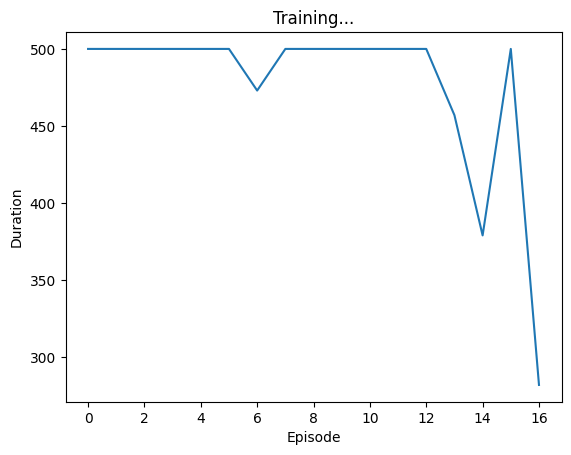

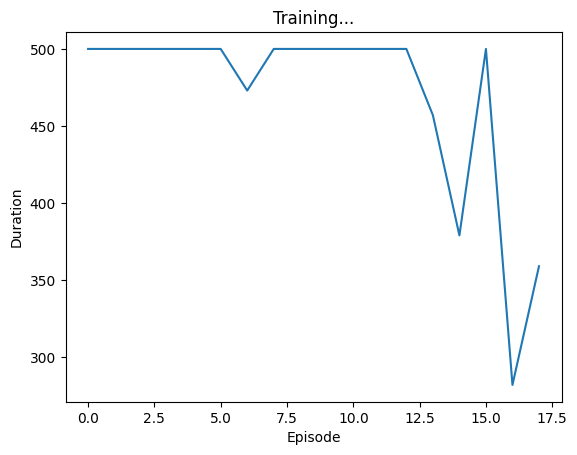

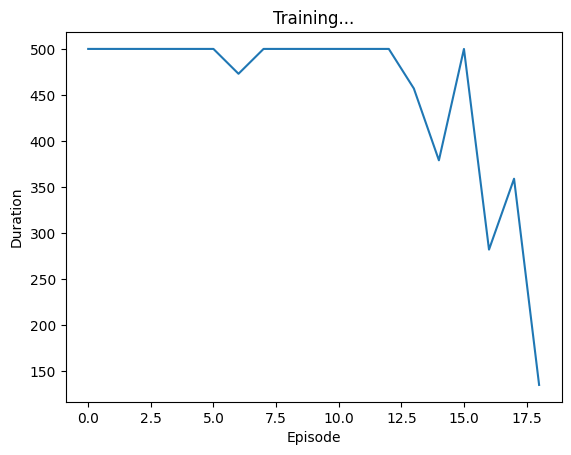

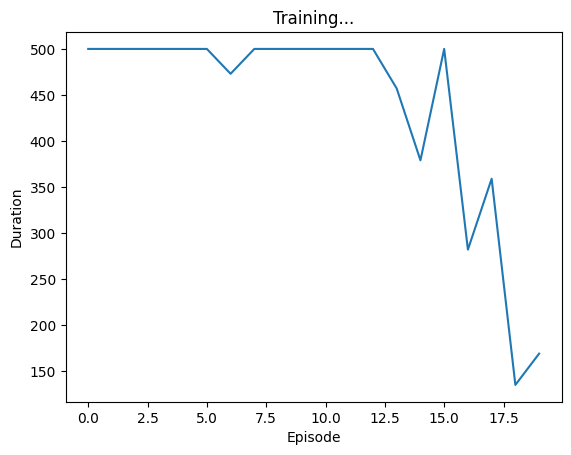

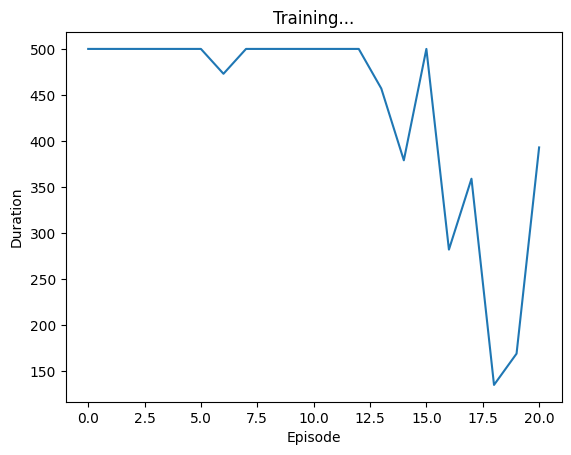

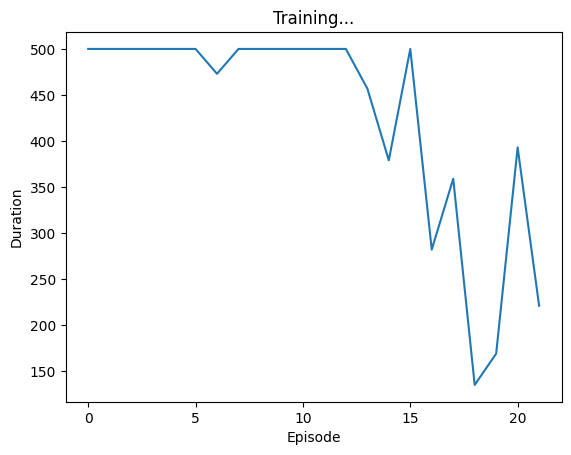

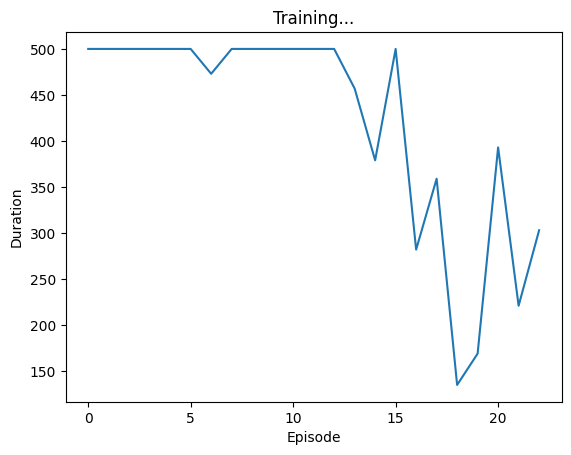

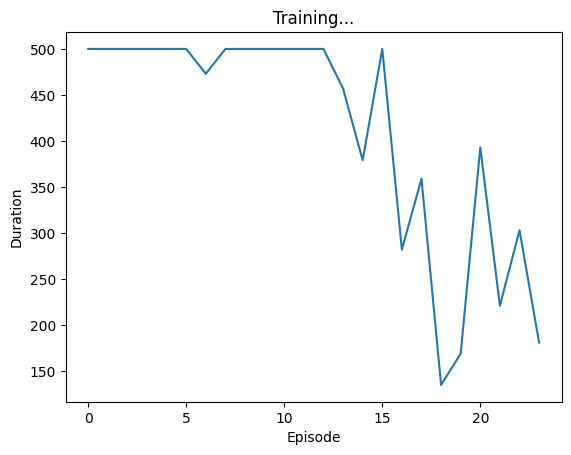

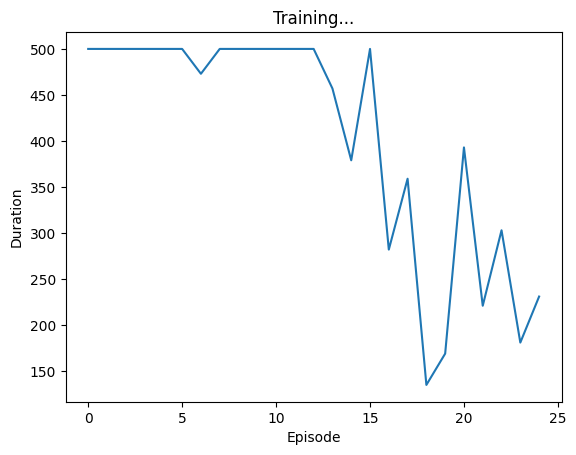

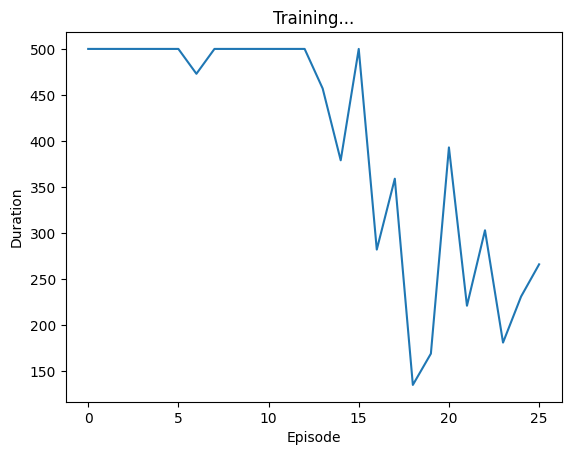

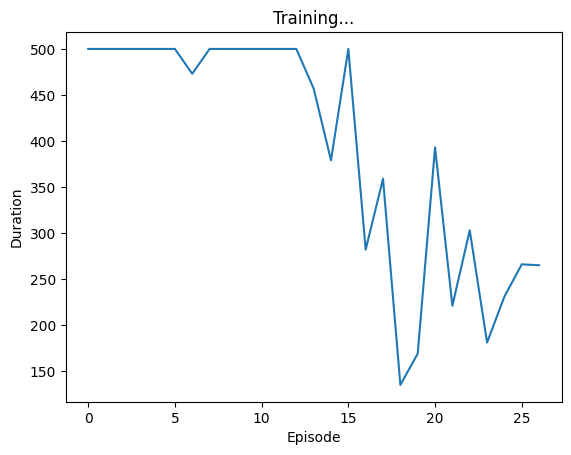

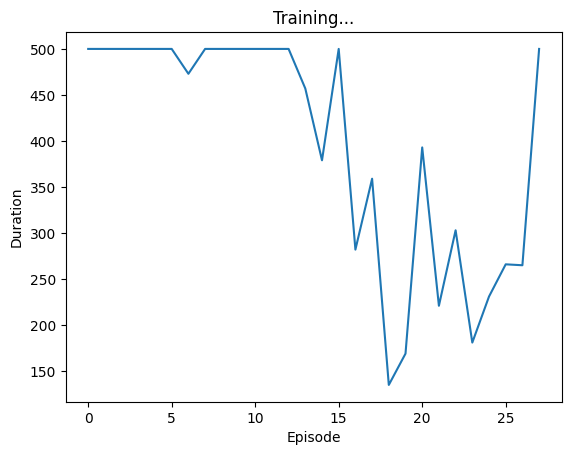

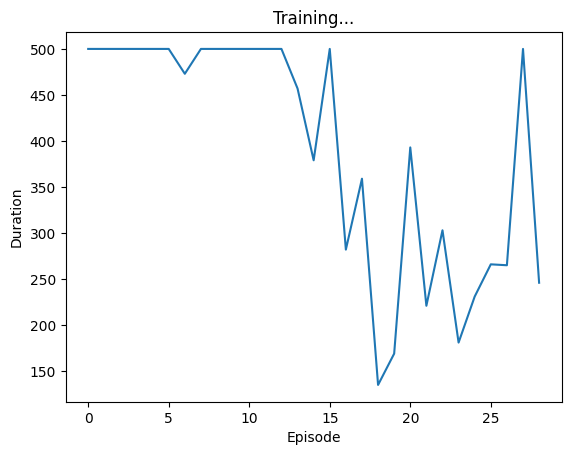

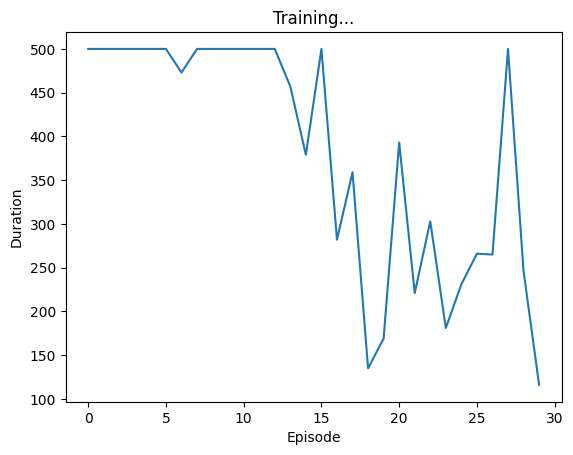

Training completed


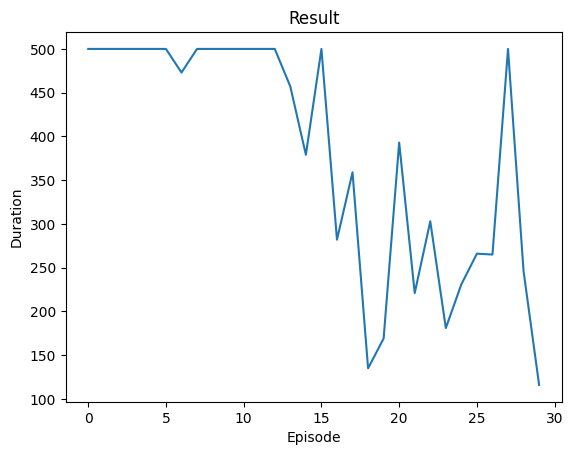

In [35]:
env = gym.make(CONST_ENV_NAME, render_mode=None)  # для обучения без рендеринга
agent = DQN_Agent(env)
agent.learn(num_episodes=30)


In [36]:
env_render = gym.make(CONST_ENV_NAME, render_mode='rgb_array')
agent.env = env_render
agent.play_agent(num_episodes=5)


Episode 1: Duration = 207, Total Reward = -206.0
Episode 2: Duration = 157, Total Reward = -156.0
Episode 3: Duration = 428, Total Reward = -427.0
Episode 4: Duration = 153, Total Reward = -152.0
Episode 5: Duration = 184, Total Reward = -183.0
